# SL Spectrum Verification Notebook

Verification and visualization of the Sturm-Liouville eigenvalue problem:

$$-\frac{d}{dr}\!\left[p(r)\frac{dR}{dr}\right] + Q(r)\,R = k^2\,w(r)\,R$$

with $\gamma_{rr}(r) = 1 + 1/r$ and
$$p(r) = \frac{r^2}{\sqrt{\gamma_{rr}}}, \quad Q(r) = \ell(\ell+1)\sqrt{\gamma_{rr}}, \quad w(r) = r^2\sqrt{\gamma_{rr}}$$

**Verification tests performed:**
1. Grid and metric consistency
2. Eigenvalue residual: $\|AR_j - k_j^2 M R_j\| / k_j^2 \|MR_j\|$
3. $w$-orthonormality of modes
4. Comparison with flat-space spherical Bessel functions (large $r$ limit)
5. Completeness: discrete $\delta$-function reconstruction

**Memory-safe update:** this version streams the HDF5 data by $\ell$ and avoids keeping the full `modes[ell]` dictionary in memory.

In [3]:
# Cell 1 — Imports and configuration
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import spherical_jn, spherical_yn
from scipy.sparse import diags
from scipy.sparse.linalg import norm as spnorm

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 130,
})

HDF5_FILE = 'sl_spectrum.h5'

In [4]:
# Cell 2 — Load only metadata and define on-demand HDF5 readers
#
# Memory-safe strategy:
#   - Keep only r_full, r, dr, drc and metadata in memory.
#   - Do NOT build modes[ell] or ks[ell] dictionaries.
#   - Read each ell group only inside the cell/loop where it is needed.
#   - Slice modes whenever possible, e.g. first n modes or only r <= r_plot_max.
#
# Robustness note:
#   Some large files may store params/integer with n_save = -1 or another
#   placeholder value. Therefore n_save is inferred directly from the HDF5
#   datasets, not from params/integer.

with h5py.File(HDF5_FILE, 'r') as f:
    r_full      = f['r'][:]                       # shape (Nr+2,): ghost/boundary + interior
    params_real = f['params/real'][:]             # [r_max, dr_min, dr_max, r_flat]
    params_int  = f['params/integer'][:]          # [Nr, N_intervals, ell_max, n_modes, n_save]

    available_ells = sorted(
        int(name.split('_')[1])
        for name in f.keys()
        if name.startswith('ell_') and name.split('_')[1].isdigit()
    )

    if len(available_ells) == 0:
        raise ValueError('No se encontraron grupos ell_#### en el archivo HDF5.')

    # Infer mode counts from the k datasets. This is the reliable source.
    n_save_by_ell = {ell: int(f[f'ell_{ell:04d}']['k'].shape[0]) for ell in available_ells}

    # Inspect the first ell group to determine the on-disk modes layout.
    raw_shape_0 = f[f'ell_{available_ells[0]:04d}']['modes'].shape

r_max, dr_min, dr_max, r_flat = params_real

Nr_meta, N_intervals_meta, ell_max_meta, n_modes_meta, n_save_meta = params_int.tolist()

# Interior grid nodes r[1] ... r[Nr]
r   = r_full[1:-1]                         # shape (Nr,)
Nr  = int(len(r))                           # robust source for Nr

dr  = np.diff(r_full)                       # shape (Nr+1,) — edge spacings
drc = 0.5*(dr[:-1] + dr[1:])                # shape (Nr,)  — cell widths

# Robust metadata used by the rest of the notebook.
N_intervals = int(N_intervals_meta)
ell_max     = int(max(available_ells))
n_save      = int(min(n_save_by_ell.values()))       # common safe count across all ell groups
n_modes     = int(n_modes_meta) if int(n_modes_meta) > 0 else n_save

if n_save <= 0:
    raise ValueError(f'n_save inválido inferido desde HDF5: n_save={n_save}')

if int(n_save_meta) != n_save:
    print(f'[INFO] params/integer n_save={int(n_save_meta)}; usando n_save inferido desde HDF5={n_save}.')
if int(ell_max_meta) != ell_max:
    print(f'[INFO] params/integer ell_max={int(ell_max_meta)}; usando ell_max inferido desde grupos HDF5={ell_max}.')
if int(Nr_meta) != Nr:
    print(f'[INFO] params/integer Nr={int(Nr_meta)}; usando Nr inferido desde r_full={Nr}.')


def _slice_from_mask(mask):
    """Return a contiguous slice equivalent to a boolean mask, when possible."""
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return slice(0, 0)
    if np.all(np.diff(idx) == 1):
        return slice(int(idx[0]), int(idx[-1]) + 1)
    # h5py supports increasing integer arrays. This fallback is slower, but safe.
    return idx.astype(np.int64)


def n_modes_for_ell(ell):
    """Number of saved modes for one ell, inferred from the HDF5 k dataset."""
    return int(n_save_by_ell[int(ell)])


def read_k(ell, j_slice=slice(None)):
    """Read k values for one ell. Usually small, so this is cheap."""
    with h5py.File(HDF5_FILE, 'r') as f:
        return np.asarray(f[f'ell_{ell:04d}']['k'][j_slice])


def read_modes(ell, j_slice=slice(None), i_slice=slice(None), dtype=None):
    """
    Read modes for one ell from HDF5.

    Returns an array with shape:
        (Nr_selected, n_modes_selected)

    It works for either on-disk layout:
        (n_save, Nr)  or  (Nr, n_save)
    """
    with h5py.File(HDF5_FILE, 'r') as f:
        dset = f[f'ell_{ell:04d}']['modes']

        if dset.shape[1] == Nr:
            # Raw layout: (n_save, Nr)
            arr = np.asarray(dset[j_slice, i_slice])
            if arr.ndim == 2:
                arr = arr.T

        elif dset.shape[0] == Nr:
            # Raw layout: (Nr, n_save)
            arr = np.asarray(dset[i_slice, j_slice])

        else:
            raise ValueError(
                f'No reconozco la forma de modes para ell={ell}: '
                f'dset.shape={dset.shape}, Nr={Nr}'
            )

    if dtype is not None:
        arr = arr.astype(dtype, copy=False)

    return arr


def read_mode(ell, j, i_slice=slice(None), dtype=None):
    """Read a single mode R_j(r) for one ell as a 1D array."""
    with h5py.File(HDF5_FILE, 'r') as f:
        dset = f[f'ell_{ell:04d}']['modes']

        if dset.shape[1] == Nr:
            # Raw layout: (n_save, Nr)
            arr = np.asarray(dset[j, i_slice])

        elif dset.shape[0] == Nr:
            # Raw layout: (Nr, n_save)
            arr = np.asarray(dset[i_slice, j])

        else:
            raise ValueError(
                f'No reconozco la forma de modes para ell={ell}: '
                f'dset.shape={dset.shape}, Nr={Nr}'
            )

    if dtype is not None:
        arr = arr.astype(dtype, copy=False)

    return arr


def h5_mode_shape(ell=0):
    """Return the raw on-disk shape of ell modes."""
    with h5py.File(HDF5_FILE, 'r') as f:
        return f[f'ell_{ell:04d}']['modes'].shape


raw_shape = h5_mode_shape(available_ells[0])
print(f'Nr={Nr}, N_intervals={N_intervals}, ell_max={ell_max}, n_save={n_save}')
print(f'available ell groups: {available_ells[0]} ... {available_ells[-1]}  ({len(available_ells)} groups)')
print(f'r_min={r[0]:.4f},  r_max_interior={r[-1]:.1f}')
print(f'Raw HDF5 modes shape for ell={available_ells[0]}: {raw_shape}')
print('Memory mode: streaming by ell; no modes[ell] dictionary is created.')


[INFO] params/integer n_save=-1; usando n_save inferido desde HDF5=5200.
Nr=10214, N_intervals=10215, ell_max=160, n_save=5200
available ell groups: 0 ... 160  (161 groups)
r_min=0.1000,  r_max_interior=9999.2
Raw HDF5 modes shape for ell=0: (5200, 10214)
Memory mode: streaming by ell; no modes[ell] dictionary is created.


p(r)/r^2 == 1/sqrt(gamma_rr)  max error: 1.11e-16  ✓


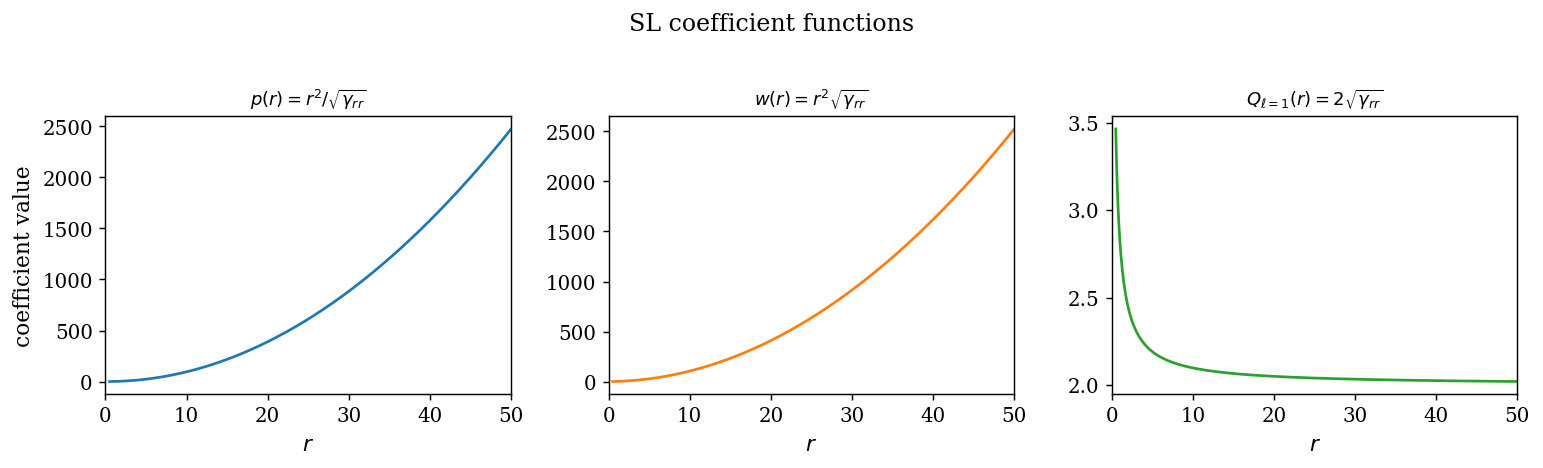

In [5]:
# Cell 3 — Metric functions and mass matrix

def gamma_rr(r): return 1.0 + 1.0/r
def p_func(r):   return r**2 / np.sqrt(gamma_rr(r))
def w_func(r):   return r**2 * np.sqrt(gamma_rr(r))
def Q_func(ell, r): return ell*(ell+1) * np.sqrt(gamma_rr(r))

# Mass matrix diagonal
mdiag = w_func(r) * drc     # shape (Nr,)

# Verify consistency: p/r^2 should equal Q/[ell*(ell+1)] for ell>0
r_test = np.linspace(2, 100, 500)
rel_err = np.max(np.abs(p_func(r_test)/r_test**2 - 1.0/np.sqrt(gamma_rr(r_test))))
print(f'p(r)/r^2 == 1/sqrt(gamma_rr)  max error: {rel_err:.2e}  ✓' if rel_err < 1e-14 else '✗')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, func, label, color in zip(
        axes,
        [p_func, w_func, lambda r: Q_func(1, r)],
        [r'$p(r) = r^2/\sqrt{\gamma_{rr}}$',
         r'$w(r) = r^2\sqrt{\gamma_{rr}}$',
         r'$Q_{\ell=1}(r) = 2 \sqrt{\gamma_{rr}}$'],
        ['C0', 'C1', 'C2']):
    r_plot = np.linspace(0.5, 50, 500)
    ax.plot(r_plot, func(r_plot), color=color)
    ax.set_xlabel(r'$r$');  ax.set_title(label, fontsize=10)
    ax.set_xlim(0, 50)

axes[0].set_ylabel('coefficient value')
fig.suptitle('SL coefficient functions', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Cell 4 — Reconstruct FV matrices A and M

def build_A_sparse(Nr, ell, r_full, dr):
    """
    Build the FV stiffness matrix A (sparse, Nr x Nr).
    Uses same discretization as the Fortran code.
    """
    r_int  = r_full[1:-1]                        # interior nodes
    p_face = p_func(0.5*(r_full[:-1]+r_full[1:])) # p at Nr+1 faces
    p_l    = p_face[:-1]                          # left  face per cell
    p_r    = p_face[1:]                           # right face per cell
    dr_l   = dr[:-1]
    dr_r   = dr[1:]
    drc    = 0.5*(dr_l + dr_r)

    A_diag = p_r/dr_r + p_l/dr_l + Q_func(ell, r_int)*drc

    # Boundary conditions
    if ell == 0:
        A_diag[0]  -= p_l[0] / dr_l[0]    # Neumann left  (ell=0)
    A_diag[-1] -= p_r[-1] / dr_r[-1]       # Neumann right (all ell)

    A_off  = -p_face[1:-1] / dr[1:-1]     # off-diagonal (-p_{i+1/2}/dr_i)

    return diags([A_off, A_diag, A_off], [-1, 0, 1], format='csr')


# Quick build for ell=0
A0 = build_A_sparse(Nr, 0, r_full, dr)
print(f'A matrix shape: {A0.shape},  nnz: {A0.nnz}')
print(f'A symmetry check: ||A - A.T||_F = {spnorm(A0 - A0.T, "fro"):.2e}')

A matrix shape: (10214, 10214),  nnz: 30640
A symmetry check: ||A - A.T||_F = 0.00e+00


In [7]:
# Cell 5 — Eigenvalue residual test
# Tests: A @ R_j - k_j^2 * M * R_j ≈ 0
#
# Streaming version: for each ell, read only the first n_check modes.

print(f"{'ell':>4}  {'j':>5}  {'k_j':>12}  {'rel residual':>14}")
print('-' * 42)

for ell in available_ells:
    A = build_A_sparse(Nr, ell, r_full, dr)

    k = read_k(ell)
    n_check = min(10, len(k))
    k = k[:n_check]
    k2 = k**2

    # Load only this ell and only the modes checked here: shape (Nr, n_check)
    R = read_modes(ell, j_slice=slice(0, n_check))

    rel_values = []
    for j in range(n_check):
        Rj  = R[:, j]
        res = A @ Rj - k2[j] * mdiag * Rj
        denom = k2[j] * np.linalg.norm(mdiag * Rj)
        rel   = np.linalg.norm(res) / denom if denom > 0 else np.nan
        rel_values.append(rel)
        if j < 3:             # print first 3 per ell
            print(f'{ell:>4}  {j:>5}  {k[j]:>12.6f}  {rel:>14.3e}')

    max_rel = np.nanmax(rel_values)
    print(f'  --> ell={ell}: max relative residual (first {n_check} modes) = {max_rel:.2e}')
    print()


 ell      j           k_j    rel residual
------------------------------------------
   0      0      0.000000       8.395e+01
   0      1      0.000449       1.191e-07
   0      2      0.000772       4.073e-08
  --> ell=0: max relative residual (first 10 modes) = 8.39e+01

   1      0      0.000208       4.070e-07
   1      1      0.000594       6.671e-08
   1      2      0.000921       2.795e-08
  --> ell=1: max relative residual (first 10 modes) = 4.07e-07

   2      0      0.000334       1.515e-07
   2      1      0.000729       4.303e-08
   2      2      0.001061       2.114e-08
  --> ell=2: max relative residual (first 10 modes) = 1.52e-07

   3      0      0.000451       8.180e-08
   3      1      0.000858       3.001e-08
   3      2      0.001197       1.601e-08
  --> ell=3: max relative residual (first 10 modes) = 8.18e-08

   4      0      0.000565       5.036e-08
   4      1      0.000984       2.209e-08
   4      2      0.001330       1.274e-08
  --> ell=4: max relative res

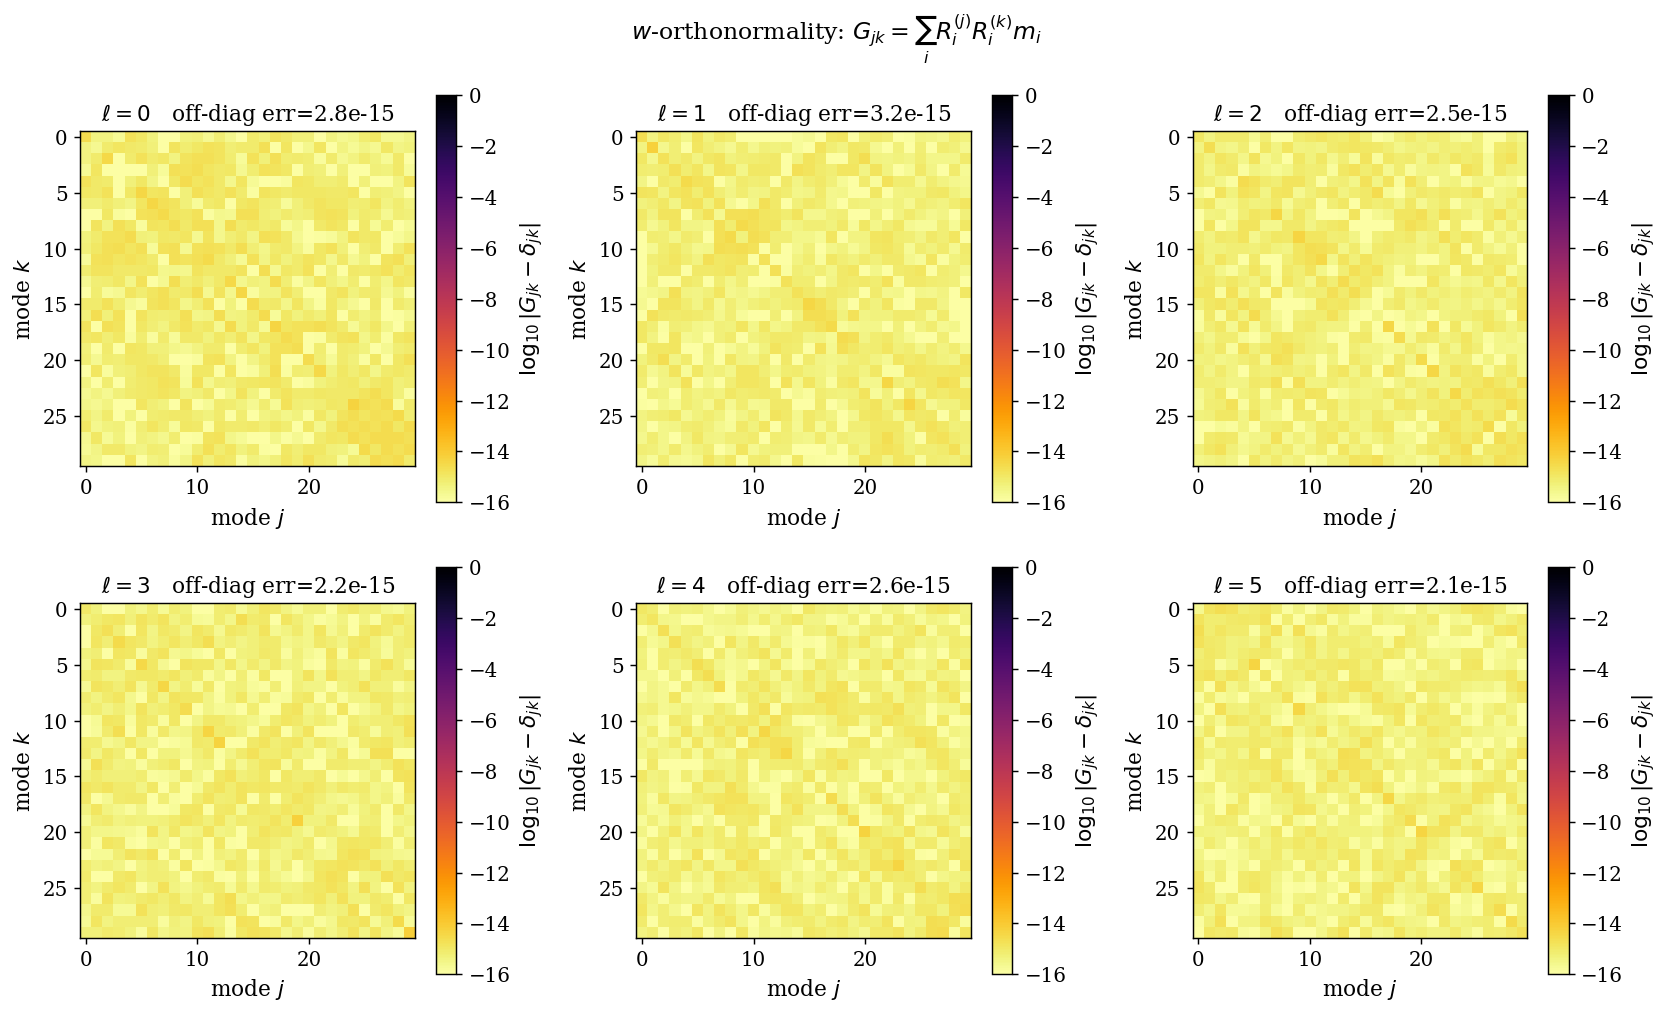

In [8]:
# Cell 6 — w-orthonormality check
# Tests: ⟨R_j, R_k⟩_w = Σ_i R_i^j R_i^k m_i = δ_jk
#
# Streaming version: plot only a small subset of ell values and load only n_check modes.

n_check_global = min(30, n_save)
ells_to_plot = available_ells[:6]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes_flat = list(axes.flat)

for ax in axes_flat:
    ax.axis('off')

for ell, ax in zip(ells_to_plot, axes_flat):
    ax.axis('on')

    k = read_k(ell)
    n_check = min(n_check_global, len(k))
    if n_check <= 0:
        ax.set_title(rf'$\ell={ell}$: no modes')
        ax.axis('off')
        continue

    R = read_modes(ell, j_slice=slice(0, n_check))      # (Nr, n_check)

    # Gram matrix G[j,k] = Σ_i R_i^j * R_i^k * m_i
    G      = (R * mdiag[:, None]).T @ R                 # (n_check, n_check)
    err    = G - np.eye(n_check)
    offdiag_err = np.max(np.abs(err - np.diag(np.diag(err))))
    diag_err    = np.max(np.abs(np.diag(err)))

    im = ax.imshow(np.log10(np.abs(err) + 1e-18), vmin=-16, vmax=0,
                   cmap='inferno_r', aspect='equal')
    ax.set_title(rf'$\ell={ell}$   off-diag err={offdiag_err:.1e}')
    ax.set_xlabel('mode $j$');  ax.set_ylabel('mode $k$')
    plt.colorbar(im, ax=ax, label=r'$\log_{10}|G_{jk}-\delta_{jk}|$')

fig.suptitle(r'$w$-orthonormality: $G_{jk} = \sum_i R_i^{(j)} R_i^{(k)} m_i$', fontsize=13)
plt.tight_layout()
plt.show()


<>:35: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_23031/1477878965.py:35: SyntaxWarning: invalid escape sequence '\ '
  ax.plot(r_plot, Rj, color=c, lw=1.2, label=f'$j={j},\ k={k[j]:.4f}$')
/tmp/ipykernel_23031/1477878965.py:43: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle('Lowest eigenmodes $R_\ell(r)$ per $\ell$', fontsize=13)


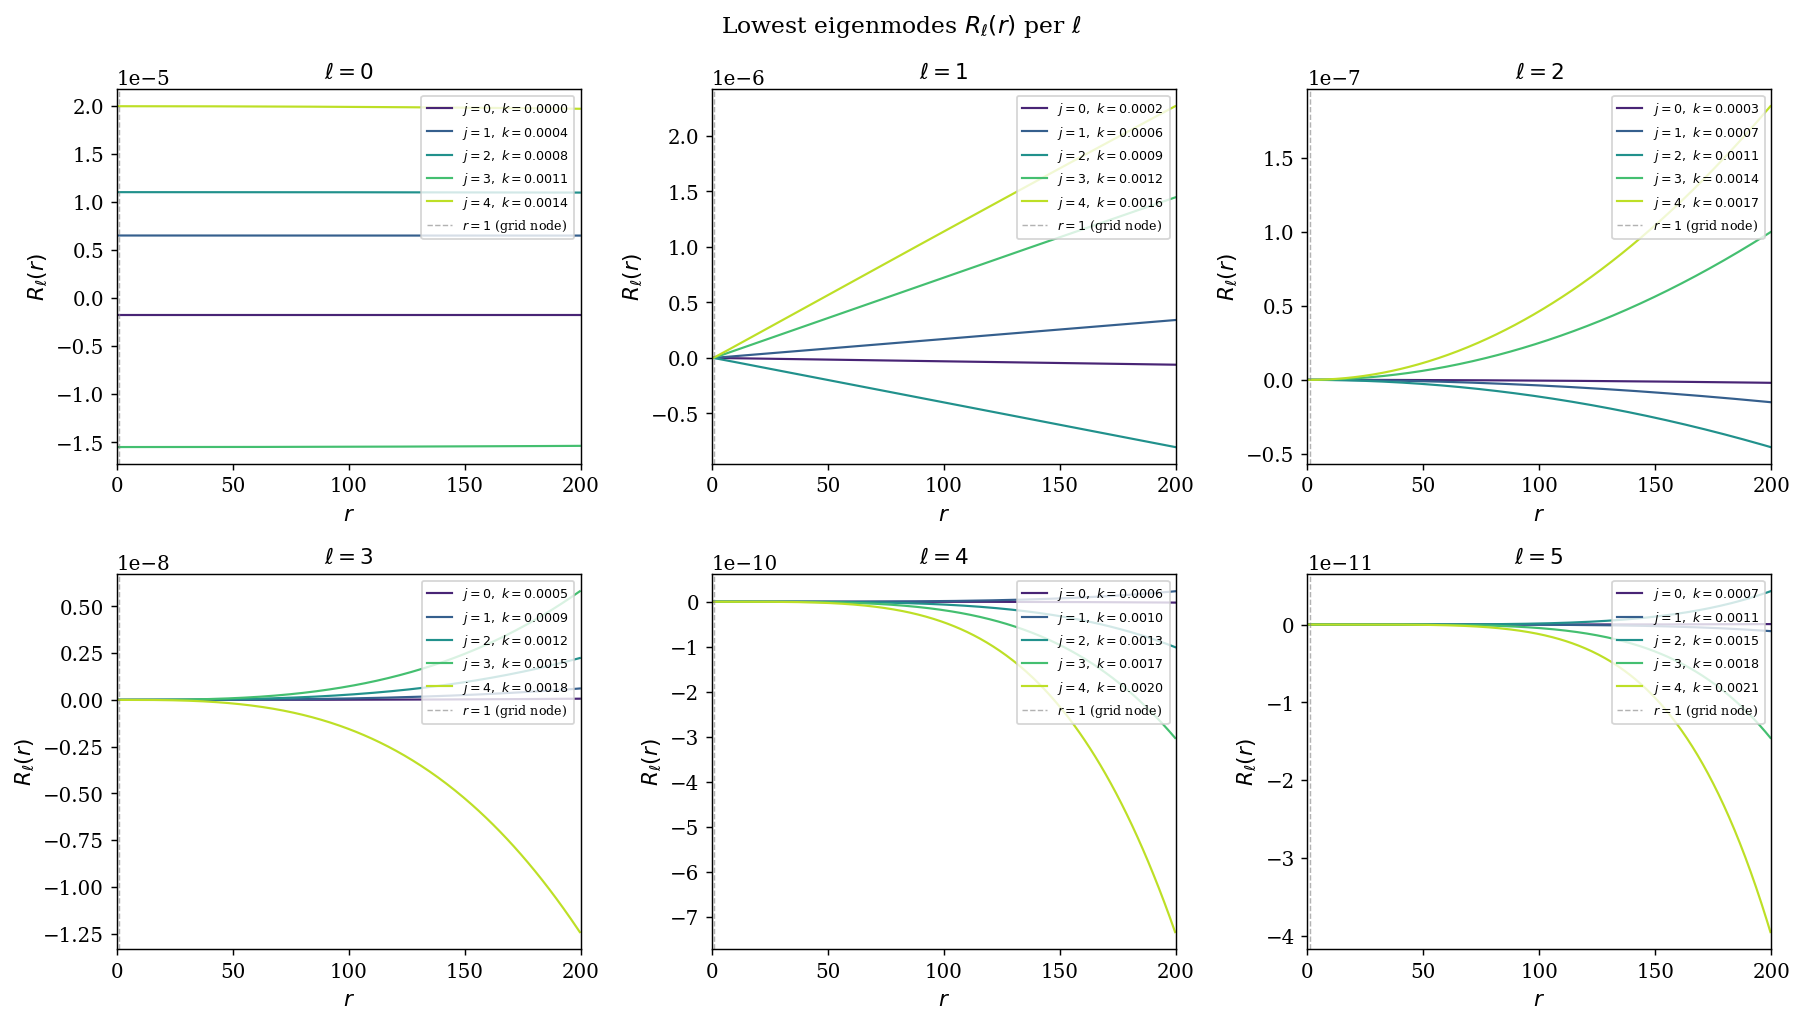

In [9]:
# Cell 7 — Mode visualization per ell
#
# Streaming version: read only r <= r_plot_max and only the lowest n_show modes.

r_plot_max = 200.0
mask       = r <= r_plot_max
i_plot     = _slice_from_mask(mask)
r_plot     = r[mask]

n_show_global = min(5, n_save)
ells_to_plot = available_ells[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes_flat = list(axes.flat)

for ax in axes_flat:
    ax.axis('off')

for ell, ax in zip(ells_to_plot, axes_flat):
    ax.axis('on')

    k = read_k(ell)
    n_show = min(n_show_global, len(k))
    if n_show <= 0:
        ax.set_title(rf'$\ell={ell}$: no modes')
        ax.axis('off')
        continue

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_show))
    R = read_modes(ell, j_slice=slice(0, n_show), i_slice=i_plot)  # (len(r_plot), n_show)
    k = k[:n_show]

    for j, c in enumerate(colors):
        Rj = R[:, j]
        ax.plot(r_plot, Rj, color=c, lw=1.2, label=f'$j={j},\ k={k[j]:.4f}$')
    ax.axvline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6, label='$r=1$ (grid node)')
    ax.set_title(rf'$\ell = {ell}$')
    ax.set_xlabel(r'$r$')
    ax.set_ylabel(r'$R_\ell(r)$')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0, r_plot_max)

fig.suptitle('Lowest eigenmodes $R_\ell(r)$ per $\ell$', fontsize=13)
plt.tight_layout()
plt.show()


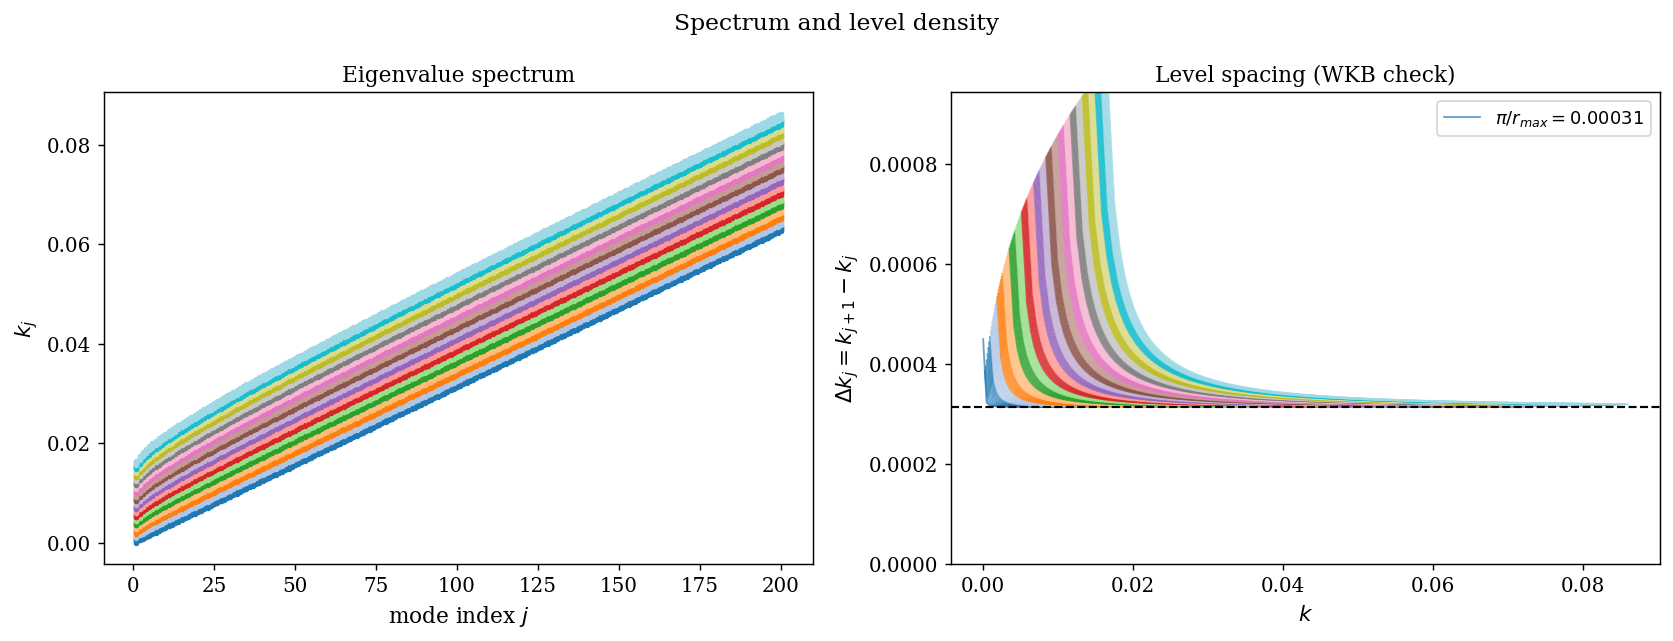

In [10]:
# Cell 8 — Eigenvalue spectrum (k_j vs j) for all ell
#
# Streaming version: read only k arrays. These are small compared with the modes.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

n_spec_global = min(200, n_save)
colors = plt.cm.tab20(np.linspace(0, 1, len(available_ells)))

for ell, c in zip(available_ells, colors):
    k_all = read_k(ell)
    n_spec = min(n_spec_global, len(k_all))
    if n_spec <= 0:
        continue
    k = k_all[:n_spec]
    ax1.plot(np.arange(1, len(k)+1), k, 'o', ms=2, color=c, label=rf'$\ell={ell}$')

ax1.set_xlabel('mode index $j$')
ax1.set_ylabel(r'$k_j$')
ax1.set_title('Eigenvalue spectrum')
if len(available_ells) <= 20:
    ax1.legend()

# Level density: dk/dj should be approximately pi/r_max (WKB for free field)
k_wkb  = np.pi / r_max   # expected mean spacing (Weyl law, flat space)
for ell, c in zip(available_ells, colors):
    k_all = read_k(ell)
    n_spec = min(n_spec_global, len(k_all))
    if n_spec <= 1:
        continue
    k = k_all[:n_spec]
    dk = np.diff(k)
    ax2.plot(k[:-1], dk, '-', lw=1.0, color=c, alpha=0.7, label=rf'$\ell={ell}$')

ax2.axhline(k_wkb, color='k', ls='--', lw=1.2, label=rf'$\pi/r_{{max}} = {k_wkb:.5f}$')
ax2.set_xlabel(r'$k$')
ax2.set_ylabel(r'$\Delta k_j = k_{j+1} - k_j$')
ax2.set_title('Level spacing (WKB check)')
if len(available_ells) <= 20:
    ax2.legend()
else:
    ax2.legend([rf'$\pi/r_{{max}} = {k_wkb:.5f}$'])
ax2.set_ylim(0, 3*k_wkb)

fig.suptitle('Spectrum and level density', fontsize=13)
plt.tight_layout()
plt.show()


<>:57: SyntaxWarning: invalid escape sequence '\ '
<>:65: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\ '
<>:65: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_23031/2295850257.py:57: SyntaxWarning: invalid escape sequence '\ '
  ax.plot(r_far, Rj,         color=c, lw=2.0, label=f'$j={j},\ k={kj:.4f}$')
/tmp/ipykernel_23031/2295850257.py:65: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle(f'Asymptotic comparison with flat-space $j_\ell(kr)$  ($r > {r_start}$)', fontsize=12)


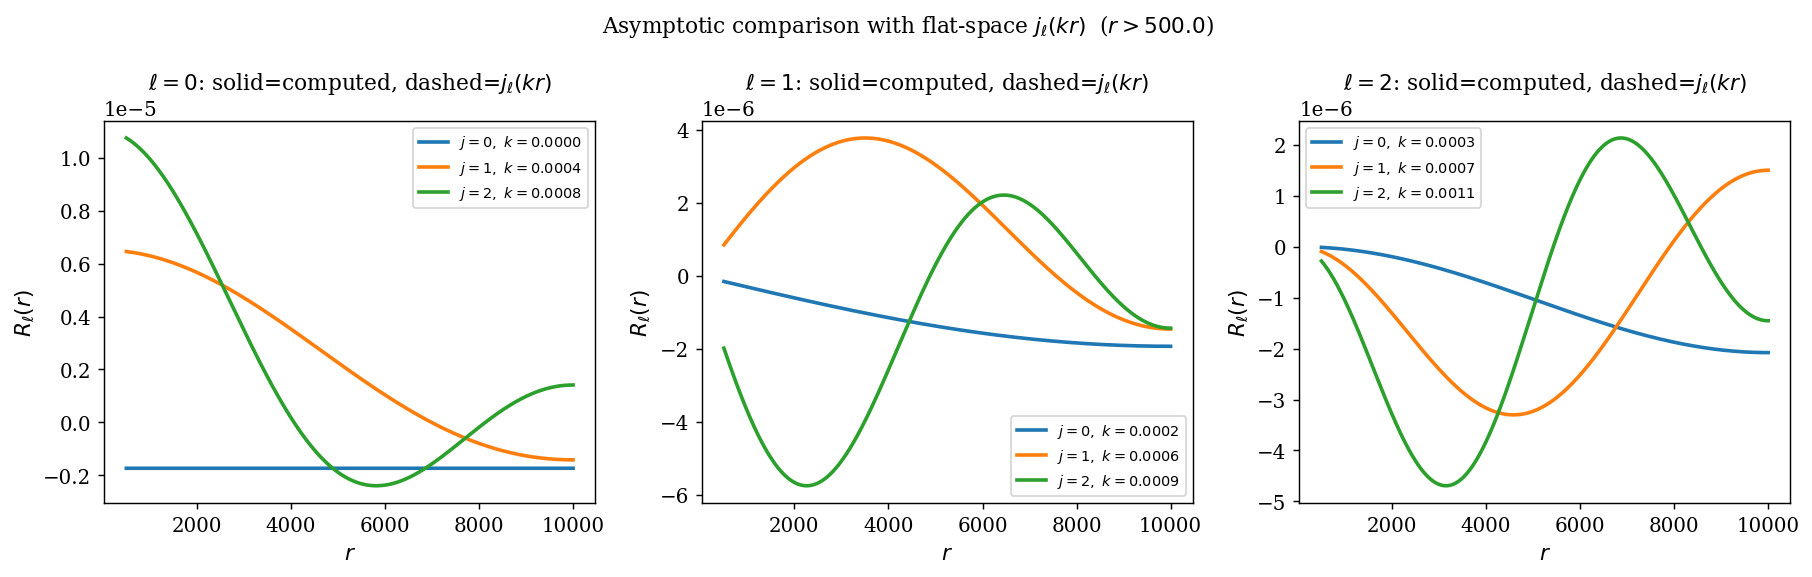

In [11]:
# Cell 9 — Flat-space comparison (large-r Bessel limit)
#
# For r >> 1:  gamma_rr -> 1, so p -> r^2, Q -> ell*(ell+1), w -> r^2.
# The SL equation reduces to the free-field radial equation:
#   -1/r^2 d/dr[r^2 dR/dr] + ell*(ell+1)/r^2 R = k^2 R
# with solutions j_ell(kr) (regular) and y_ell(kr) (irregular).
# Eigenmode with Neumann BC at r_max: j_ell(k*r_max)' = 0,
# i.e., k_{j,free} = zeros of d/d(kr)[r^{ell+1} j_ell(kr)] / r^{ell+1}.
#
# Streaming version: read only the far-r region and only the first three modes.

r_start = 500.0    # asymptotic comparison region
mask_far = r > r_start

# If the test file/domain is smaller than r_start, fall back to the outer half.
if not np.any(mask_far):
    r_start = 0.5 * r[-1]
    mask_far = r > r_start

i_far    = _slice_from_mask(mask_far)
r_far    = r[mask_far]
mdiag_far = mdiag[mask_far]

ells_compare = [ell for ell in [0, 1, 2] if ell in available_ells]
if len(ells_compare) == 0:
    raise ValueError('No hay grupos ell=0,1,2 disponibles para esta comparación.')

fig, axes = plt.subplots(1, len(ells_compare), figsize=(4.7*len(ells_compare), 4.5), squeeze=False)
axes = axes.ravel()

for ax, ell in zip(axes, ells_compare):
    k_all = read_k(ell)
    n_compare = min(3, len(k_all))
    if n_compare <= 0:
        ax.set_title(rf'$\ell={ell}$: no modes')
        ax.axis('off')
        continue

    k = k_all[:n_compare]
    R = read_modes(ell, j_slice=slice(0, n_compare), i_slice=i_far)

    for j in range(n_compare):
        kj = k[j]
        Rj = R[:, j]

        # Flat-space ansatz: R_free(r) = A * j_ell(k*r)
        jl    = spherical_jn(ell, kj * r_far)
        denom = (jl**2 * mdiag_far).sum()
        if denom == 0:
            continue

        # Fit amplitude (least squares)
        amp   = (Rj * jl * mdiag_far).sum() / denom
        R_bessel = amp * jl

        c = f'C{j}'
        ax.plot(r_far, Rj,         color=c, lw=2.0, label=f'$j={j},\ k={kj:.4f}$')
        ax.plot(r_far, R_bessel,   color=c, lw=1.0, ls='--', alpha=0.7)

    ax.set_xlabel(r'$r$')
    ax.set_ylabel(r'$R_{\ell}(r)$')
    ax.set_title(rf'$\ell={ell}$: solid=computed, dashed=$j_\ell(kr)$')
    ax.legend(fontsize=8)

fig.suptitle(f'Asymptotic comparison with flat-space $j_\ell(kr)$  ($r > {r_start}$)', fontsize=12)
plt.tight_layout()
plt.show()


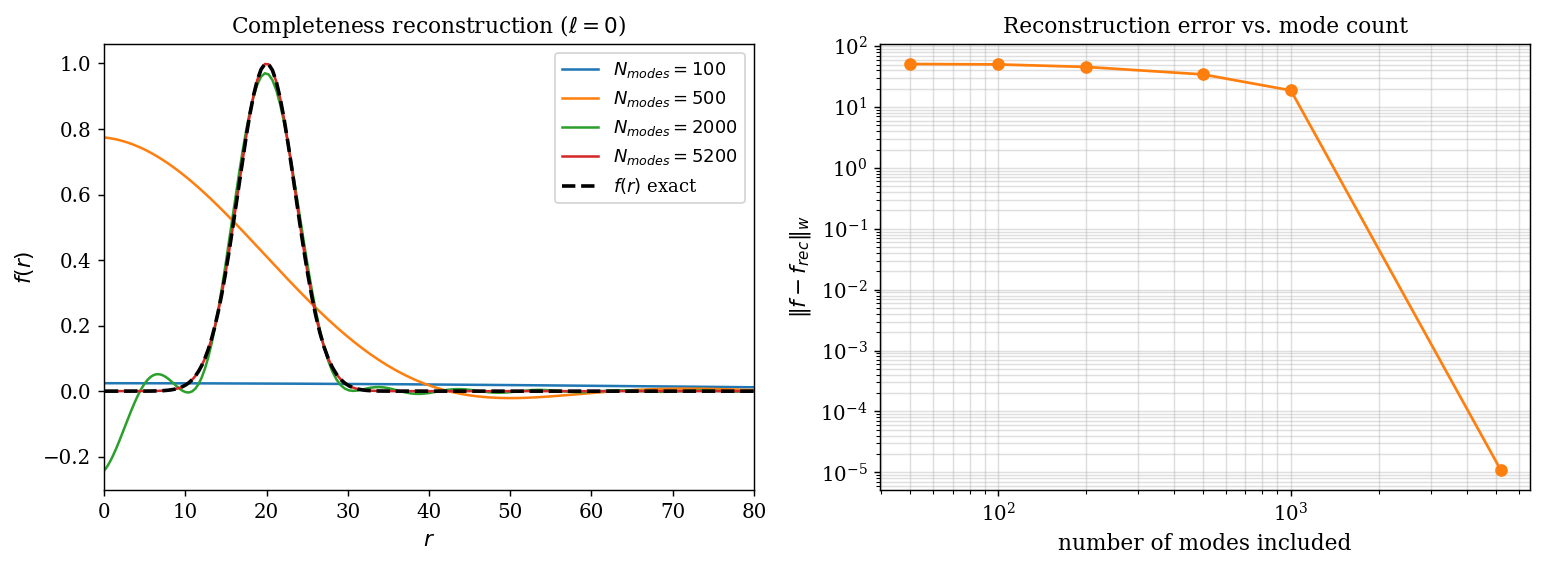

In [12]:
# Cell 10 — Completeness: discrete delta-function reconstruction
#
# The completeness relation reads:
#   Σ_j R_i^(j) R_i'^(j) = δ_i i' / m_i
# We check it by reconstructing a smooth test function f(r) via
#   fhat_j = Σ_i f(r_i) R_i^(j) m_i     (discrete inner product)
#   f_rec(r) = Σ_j fhat_j R^(j)(r)
# and comparing f_rec with f.
#
# Streaming version: project and reconstruct in mode blocks. This avoids loading
# the full (Nr, n_save) array for a single ell.

ell = available_ells[0]
f   = np.exp(-((r - 20.0)/5.0)**2)      # Gaussian test function

MODE_BLOCK = 128                         # increase if memory allows
n_modes_available = n_modes_for_ell(ell)

if n_modes_available <= 0:
    raise ValueError(f'No hay modos disponibles para ell={ell}.')


def projection_coefficients_streaming(ell, f, block=MODE_BLOCK):
    """Compute fhat_j = Σ_i f_i R_i^j m_i by reading modes in blocks."""
    n_avail = n_modes_for_ell(ell)
    fhat = np.empty(n_avail, dtype=np.float64)
    weighted_f = f * mdiag
    for j0 in range(0, n_avail, block):
        j1 = min(j0 + block, n_avail)
        R_block = read_modes(ell, j_slice=slice(j0, j1))     # (Nr, block)
        fhat[j0:j1] = weighted_f @ R_block
    return fhat


def reconstruct_streaming(ell, fhat, n_modes_use, block=MODE_BLOCK):
    """Compute f_rec(r) = Σ_j fhat_j R_j(r) without loading all modes."""
    f_rec = np.zeros_like(r, dtype=np.float64)
    n_modes_use = min(int(n_modes_use), len(fhat), n_modes_for_ell(ell))
    if n_modes_use <= 0:
        return f_rec
    for j0 in range(0, n_modes_use, block):
        j1 = min(j0 + block, n_modes_use)
        R_block = read_modes(ell, j_slice=slice(j0, j1))     # (Nr, block)
        f_rec += R_block @ fhat[j0:j1]
    return f_rec


fhat = projection_coefficients_streaming(ell, f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
n_modes_plot = [100, 500, 2000, n_modes_available]
n_modes_plot = sorted(set(min(n, n_modes_available) for n in n_modes_plot if n > 0))
for n_modes_use in n_modes_plot:
    f_rec = reconstruct_streaming(ell, fhat, n_modes_use)
    ax.plot(r, f_rec, lw=1.4, label=f'$N_{{modes}}={n_modes_use}$')

ax.plot(r, f, 'k--', lw=2, label='$f(r)$ exact')
ax.set_xlim(0, 80)
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$f(r)$')
ax.set_title(rf'Completeness reconstruction ($\ell={ell}$)')
ax.legend()

ax = axes[1]
n_modes_list = [50, 100, 200, 500, 1000, n_modes_available]
n_modes_list = sorted(set(min(n, n_modes_available) for n in n_modes_list if n > 0))
errs = []
for n in n_modes_list:
    f_rec = reconstruct_streaming(ell, fhat, n)
    errs.append(np.sqrt(((f - f_rec)**2 * mdiag).sum()))

ax.loglog(n_modes_list, errs, 'o-', color='C1')
ax.set_xlabel('number of modes included')
ax.set_ylabel(r'$\|f - f_{rec}\|_w$')
ax.set_title('Reconstruction error vs. mode count')
ax.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()


In [13]:
# Cell 11 — Diagnostic: detect q_i bug via direct SL coefficient check
#
# If the code had the bug (Q *= sqrt instead of Q /= sqrt), the
# residual A @ R_j - k_j^2 * M @ R_j will be large.
# This cell quantifies the residual and flags if it exceeds a threshold.
#
# Streaming version: for each ell, read only n_check modes.

RESIDUAL_THRESHOLD = 1e-8   # relative residual: acceptable below this

print('Eigenvalue residual summary')
print('=' * 52)
print(f"  {'ell':>4}  {'mean rel res':>14}  {'max rel res':>14}  {'status':>8}")
print('-' * 52)

for ell in available_ells:
    A = build_A_sparse(Nr, ell, r_full, dr)

    k = read_k(ell)
    n_check = min(50, len(k))
    k = k[:n_check]
    k2 = k**2
    R = read_modes(ell, j_slice=slice(0, n_check))

    rel_res = np.array([
        np.linalg.norm(A @ R[:, j] - k2[j]*mdiag*R[:, j])
        / (k2[j] * np.linalg.norm(mdiag*R[:, j]) + 1e-300)
        for j in range(n_check)
    ])
    ok = '✓ OK' if rel_res.max() < RESIDUAL_THRESHOLD else '✗ FAIL'
    print(f'  {ell:>4}  {rel_res.mean():>14.3e}  {rel_res.max():>14.3e}  {ok:>8}')

print()
print('If residuals are large (> 1e-6), check the q_i formula in the Fortran source.')
print('Bug symptom: Q(r) computed as ell*(ell+1)*sqrt(gamma_rr) instead of /sqrt(gamma_rr).')


Eigenvalue residual summary
   ell    mean rel res     max rel res    status
----------------------------------------------------
     0       1.679e+00       8.395e+01    ✗ FAIL
     1       1.134e-08       4.070e-07    ✗ FAIL
     2       5.452e-09       1.515e-07    ✗ FAIL
     3       3.568e-09       8.180e-08    ✗ FAIL
     4       2.607e-09       5.036e-08    ✗ FAIL
     5       2.048e-09       3.401e-08    ✗ FAIL
     6       1.700e-09       2.489e-08    ✗ FAIL
     7       1.434e-09       1.886e-08    ✗ FAIL
     8       1.231e-09       1.469e-08    ✗ FAIL
     9       1.099e-09       1.248e-08    ✗ FAIL
    10       9.754e-10       9.973e-09      ✓ OK
    11       8.781e-10       8.550e-09      ✓ OK
    12       7.962e-10       7.061e-09      ✓ OK
    13       7.351e-10       6.380e-09      ✓ OK
    14       6.716e-10       5.283e-09      ✓ OK
    15       6.284e-10       4.750e-09      ✓ OK
    16       5.825e-10       4.188e-09      ✓ OK
    17       5.412e-10       3.775e-0